In [ ]:
#Graph code for acccuracy vs prediciton change 

import pandas as pd 
import matplotlib.pyplot as plt 


filepath = '/Users/kanakgarg/Desktop/Kanak/FinanceRL/data/processed/prediction_sgd.csv'
model_type = 'SGD'

def plot_data_distribution(filepath, model_type):
    
    predictions_df = pd.read_csv(filepath)
    predictions_df['percentage_change'] = pd.to_numeric(predictions_df['percentage_change'], errors='coerce')
    predictions_df = predictions_df.dropna(subset=['percentage_change'])

    bins = [-100, -10, -5, -3, -1, 1, 3, 5, 10, 100]
    labels = ['-100% to -10%', '-10% to -5%', '-5% to -3%', '-3% to -1%', '-1% to 1%', '1% to 3%', '3% to 5%', '5% to 10%', '10% to 100%']

    predictions_df['percentage_bin'] = pd.cut(predictions_df['percentage_change'], bins=bins, labels=labels)

    bin_counts = predictions_df['percentage_bin'].value_counts(sort=False)

    plt.figure(figsize=(10, 6))
    bin_counts.plot(kind='bar', color='lightcoral', edgecolor='black')
    plt.xlabel('Percentage Change Bins')
    plt.ylabel('Number of Data Entries')
    plt.title(f'Data Distribution Across Percentage Change Bins for {model_type}')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


plot_data_distribution(filepath, model_type)

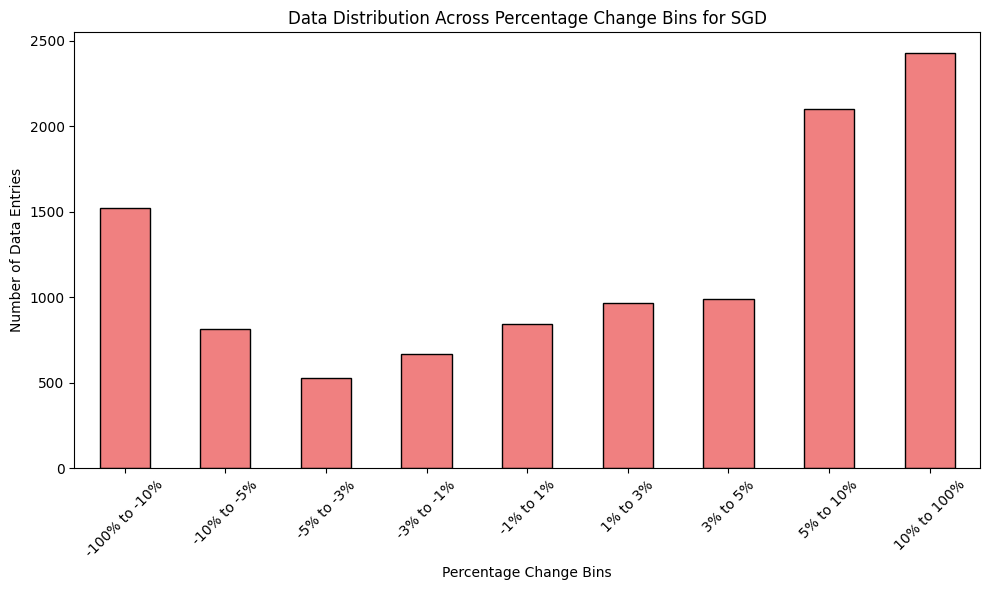

In [3]:
#Graph code for Data Distribution across all bins 

import pandas as pd 
import matplotlib.pyplot as plt 


filepath = '/Users/kanakgarg/Desktop/Kanak/FinanceRL/data/processed/prediction_sgd.csv'
model_type = 'SGD'

def plot_data_distribution(filepath, model_type):
    
    predictions_df = pd.read_csv(filepath)
    predictions_df['percentage_change'] = pd.to_numeric(predictions_df['percentage_change'], errors='coerce')
    predictions_df = predictions_df.dropna(subset=['percentage_change'])

    bins = [-100, -10, -5, -3, -1, 1, 3, 5, 10, 100]
    labels = ['-100% to -10%', '-10% to -5%', '-5% to -3%', '-3% to -1%', '-1% to 1%', '1% to 3%', '3% to 5%', '5% to 10%', '10% to 100%']

    predictions_df['percentage_bin'] = pd.cut(predictions_df['percentage_change'], bins=bins, labels=labels)

    bin_counts = predictions_df['percentage_bin'].value_counts(sort=False)

    plt.figure(figsize=(10, 6))
    bin_counts.plot(kind='bar', color='lightcoral', edgecolor='black')
    plt.xlabel('Percentage Change Bins')
    plt.ylabel('Number of Data Entries')
    plt.title(f'Data Distribution Across Percentage Change Bins for {model_type}')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

plot_data_distribution(filepath, model_type)

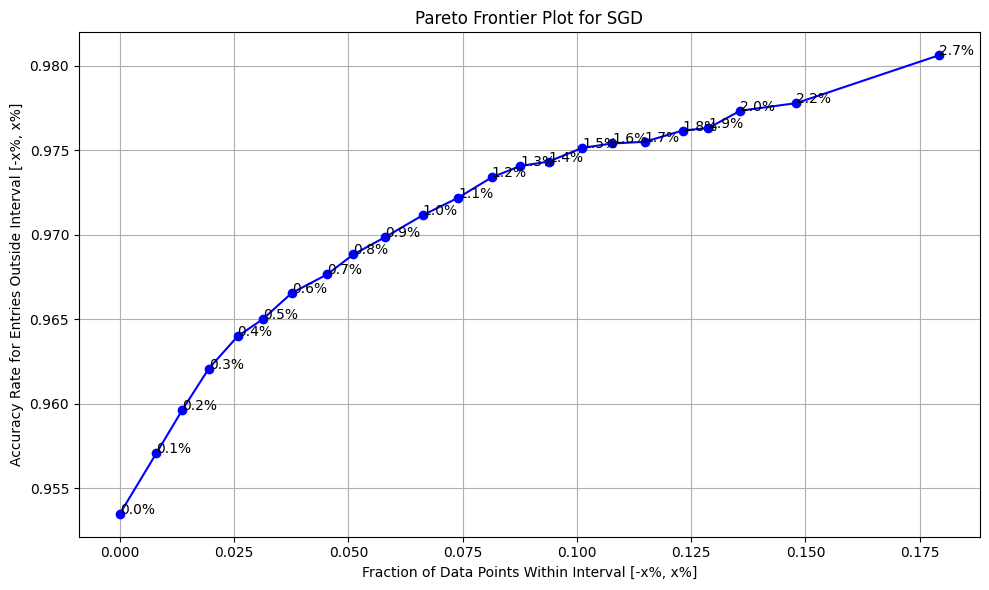

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

filepath = '/Users/kanakgarg/Desktop/Kanak/FinanceRL/data/processed/prediction_sgd.csv'
model_type = 'SGD'

def compute_accuracy_and_fraction(filepath, interval_steps, cap_fraction=0.2):
    """
    Computes the accuracy rate for predictions outside the interval [-x%, x%] and the fraction of data points within the interval.
    Caps the fraction within the interval to the specified limit and adds finer granularity for small fractions.
    """
    predictions_df = pd.read_csv(filepath)

    # Ensure columns are numeric and drop NaNs
    predictions_df['percentage_change'] = pd.to_numeric(predictions_df['percentage_change'], errors='coerce')
    predictions_df['error'] = pd.to_numeric(predictions_df['error'], errors='coerce')
    predictions_df = predictions_df.dropna(subset=['percentage_change', 'error'])

    # Determine if the prediction is correct
    predictions_df['is_correct'] = (
        ((predictions_df['direction'] == 'up') & (predictions_df['error'] > 0)) |
        ((predictions_df['direction'] == 'down') & (predictions_df['error'] < 0))
    )

    fractions_within_interval = []
    accuracy_outside_interval = []

    for x in interval_steps:
        within_interval = predictions_df[(predictions_df['percentage_change'] >= -x) & (predictions_df['percentage_change'] <= x)]
        fraction_within = len(within_interval) / len(predictions_df)

        # Cap the fraction at the specified limit
        if fraction_within > cap_fraction:
            break

        outside_interval = predictions_df[(predictions_df['percentage_change'] < -x) | (predictions_df['percentage_change'] > x)]
        accuracy_outside = outside_interval['is_correct'].mean() if len(outside_interval) > 0 else 0

        fractions_within_interval.append(fraction_within)
        accuracy_outside_interval.append(accuracy_outside)

    return fractions_within_interval, accuracy_outside_interval

def plot_pareto_frontier(fractions_within, accuracies_outside, interval_steps, model_type):
    """
    Plots the Pareto frontier: accuracy outside of the interval [-x%, x%] vs. fraction of data points within [-x%, x%].
    """
    plt.figure(figsize=(10, 6))
    plt.plot(fractions_within, accuracies_outside, marker='o', linestyle='-', color='b')
    for i, x in enumerate(interval_steps[:len(fractions_within)]):
        plt.annotate(f'{round(x, 2)}%', (fractions_within[i], accuracies_outside[i]))

    plt.xlabel('Fraction of Data Points Within Interval [-x%, x%]')
    plt.ylabel('Accuracy Rate for Entries Outside Interval [-x%, x%]')
    plt.title(f'Pareto Frontier Plot for {model_type}')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Generate interval steps with finer resolution for small fractions
interval_steps = np.concatenate((np.arange(0, 2.1, 0.1), np.arange(2.2, 20.1, 0.5)))
fractions_within, accuracies_outside = compute_accuracy_and_fraction(filepath, interval_steps, cap_fraction=0.2)
plot_pareto_frontier(fractions_within, accuracies_outside, interval_steps, model_type)
